In [62]:
from sklearn.datasets import make_regression
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
X,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

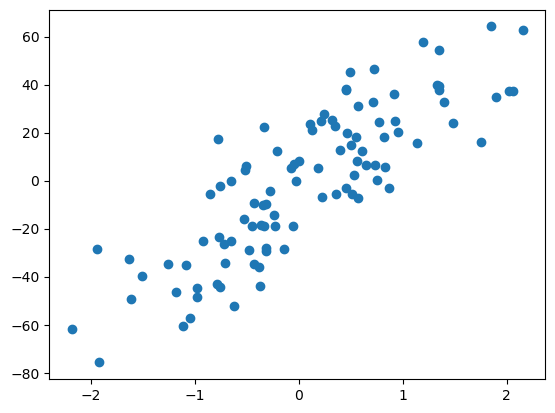

In [64]:
plt.scatter(X,y)

In [65]:
from sklearn.linear_model import LinearRegression

In [66]:
lr=LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [67]:
from sklearn.linear_model import Ridge

In [68]:
rr=Ridge(alpha=5)
rr.fit(X,y)
print(rr.coef_)
print(rr.intercept_)

[26.3131439]
-2.20626044881149


In [69]:
rr1=Ridge(alpha=100)
rr1.fit(X,y)
print(rr1.coef_)
print(rr1.intercept_)

[12.93442104]
-1.4248441496033308


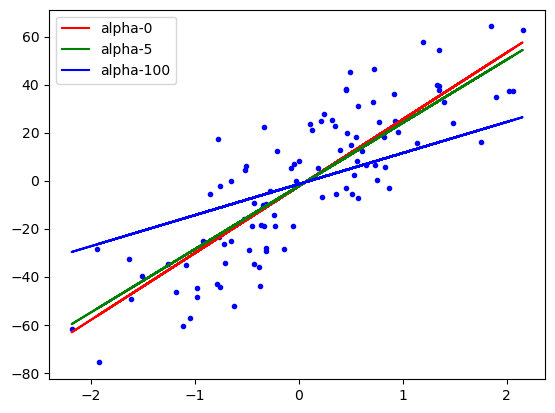

In [70]:
plt.plot(X,y,'.b')
plt.plot(X,lr.predict(X),label='alpha-0',color='red')
plt.plot(X,rr.predict(X),label='alpha-5',color='green')
plt.plot(X,rr1.predict(X),label='alpha-100',color='blue')
plt.legend()

In [71]:
import numpy as np

In [72]:
class MyRidge:
    def __init__(self,alpha=0.1):
        self.alpha=alpha
        self.m=None
        self.b=None
        
    def fit(self,X_train,y_train):
        num=0
        den=0
        for i in range(X_train.shape[0]):
            num=num+(y_train[i]-y_train.mean())*(X_train[i]-X_train.mean())
            den=den+(X_train[i]-X_train.mean())*(X_train[i]-X_train.mean())
            
        self.m=num/(den+self.alpha)
        self.b=y_train.mean()-self.m*X_train.mean()
        print(self.m)
        print(self.b)
    def predict(self,X_test):
        return np.dot(X_test,self.m)+self.b

In [73]:
reg=MyRidge(alpha=5)
reg.fit(X,y)

[26.3131439]
[-2.20626045]


### for n dimensional data

In [74]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [75]:
X1,y1=load_diabetes(return_X_y=True)

In [76]:
X_train,X_test,y_train,y_test = train_test_split(X1,y1,test_size=0.2,random_state=4)

In [78]:
rig=Ridge(alpha=0.1,solver='cholesky')
rig.fit(X_train,y_train)
y_predict=rig.predict(X_test)
r2_score(y_test,y_predict)

0.46931288533098037

In [79]:
print(rig.coef_)

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]


In [80]:
print(rig.intercept_)

150.89053425602808


In [88]:
class MeraRidge:
    
    def __init__(self,alpha=0.1):
        
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,X_train,y_train):
        
        X_train = np.insert(X_train,0,1,axis=1)
        I = np.identity(X_train.shape[1])
        I[0][0] = 0
        result = np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
        self.intercept_ = result[0]
        self.coef_ = result[1:]
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [90]:
reg = MeraRidge()
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
print(r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

0.46931288533098037
[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.89053425602808
